# ***Data Preprocessing and Model Building***

## Zoonotic Outbreak Prediction: Hybrid Federated DNN + XGBoost
## This notebook implements a hybrid model:
 - Federated Deep Neural Network (FDNN) trained locally on each client (farm, hospital, wildlife data) using FedAvg.
 - Global DNN extracts features.
 - XGBoost uses these features for final prediction.

In [52]:
# ===============================
# 1. IMPORTS
# ===============================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report

import tensorflow as tf
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)

In [53]:
# ===============================
# 2. CONFIG
# ===============================
DATA_DIR = "Datasets"
BASE_DIR = "saved_local_models"
CLIENTS = ["Farm", "Hospital", "Wildlife"]

CLIENT_FEATURES = {
    'Farm': ['Animal_Population', 'Animal_Mortality', 'Vaccination_Rate',
             'Temperature', 'Humidity', 'Rainfall', 'Contact_Index'],
    'Hospital': ['Reported_Cases', 'Mortality_Rate', 'Symptom_Count',
                 'Admissions', 'Positivity_Rate', 'Contact_Index'],
    'Wildlife': ['Species_Count', 'Migration_Flag', 'Habitat_Proximity',
                 'Wildlife_Mortality', 'Exposure_Score']
}

GLOBAL_FEATURES = [
    'Animal_Population', 'Animal_Mortality', 'Vaccination_Rate',
    'Temperature', 'Humidity', 'Rainfall', 'Contact_Index',
    'Reported_Cases', 'Mortality_Rate', 'Symptom_Count',
    'Admissions', 'Positivity_Rate',
    'Species_Count', 'Migration_Flag', 'Habitat_Proximity',
    'Wildlife_Mortality', 'Exposure_Score'
]

GLOBAL_DIM = len(GLOBAL_FEATURES)


In [56]:
# ===============================
# 3. DATA PREPROCESSING
# ===============================
def cap_outliers_iqr(df, factor=1.5):
    df_capped = df.copy()
    for col in df.columns:
        if col == "Target":
            continue
        q1, q3 = df[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower = q1 - factor * iqr
        upper = q3 + factor * iqr
        df_capped[col] = np.clip(df[col], lower, upper)
    return df_capped

def preprocess_client_data(df, client):
    X = df[CLIENT_FEATURES[client]]
    y = df["Target"]

    # Missing values
    imputer = SimpleImputer(strategy="median")
    X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

    # Outlier capping
    X_capped = cap_outliers_iqr(X_imputed)

    # Scaling
    scaler = RobustScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X_capped), columns=X.columns)

    # Align features to global
    X_global = pd.DataFrame(0, index=df.index, columns=GLOBAL_FEATURES)
    X_global[CLIENT_FEATURES[client]] = X_scaled

    return X_global, y, imputer, scaler


=== Farm CLIENT DATA EXPLORATION ===

--- Before Preprocessing ---


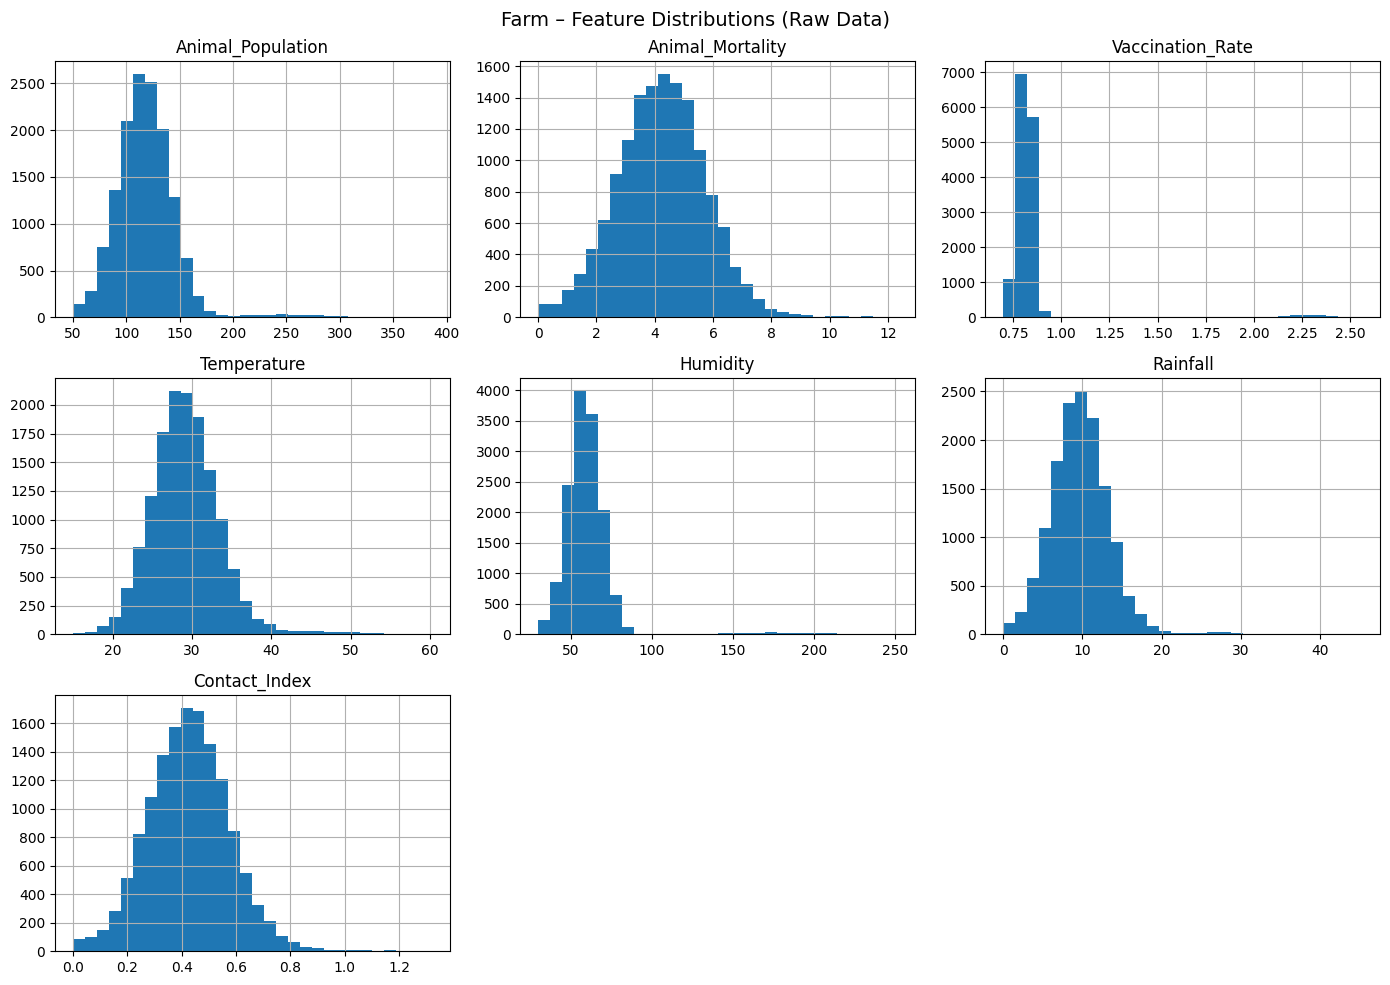

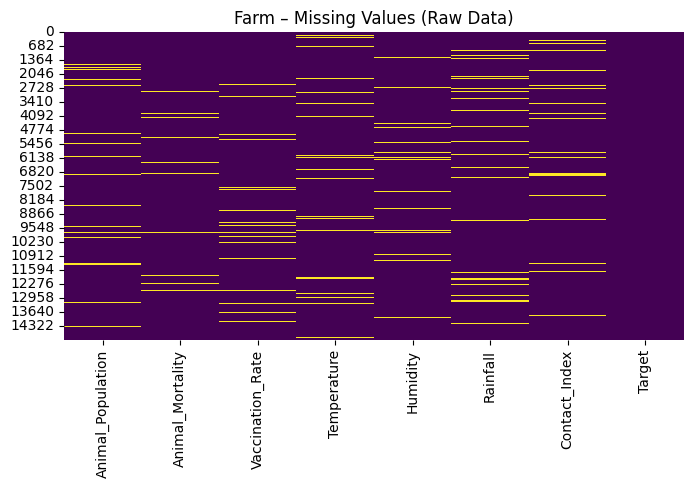

Missing values per column (Raw Data):
 Animal_Population    750
Animal_Mortality     750
Vaccination_Rate     750
Temperature          750
Humidity             750
Rainfall             750
Contact_Index        750
Target                 0
dtype: int64


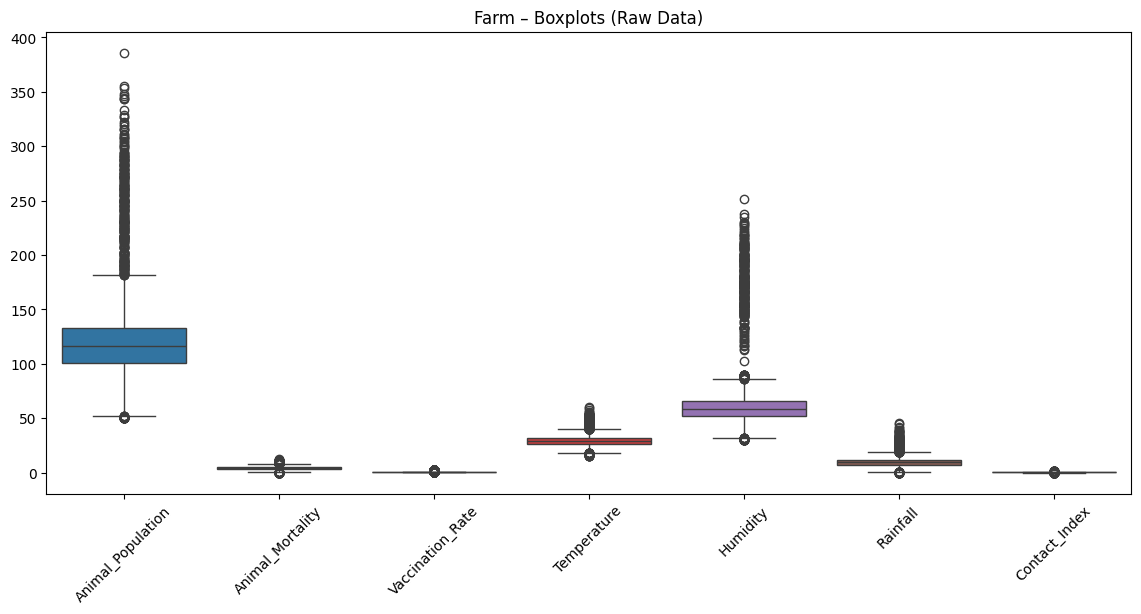


--- After Preprocessing ---


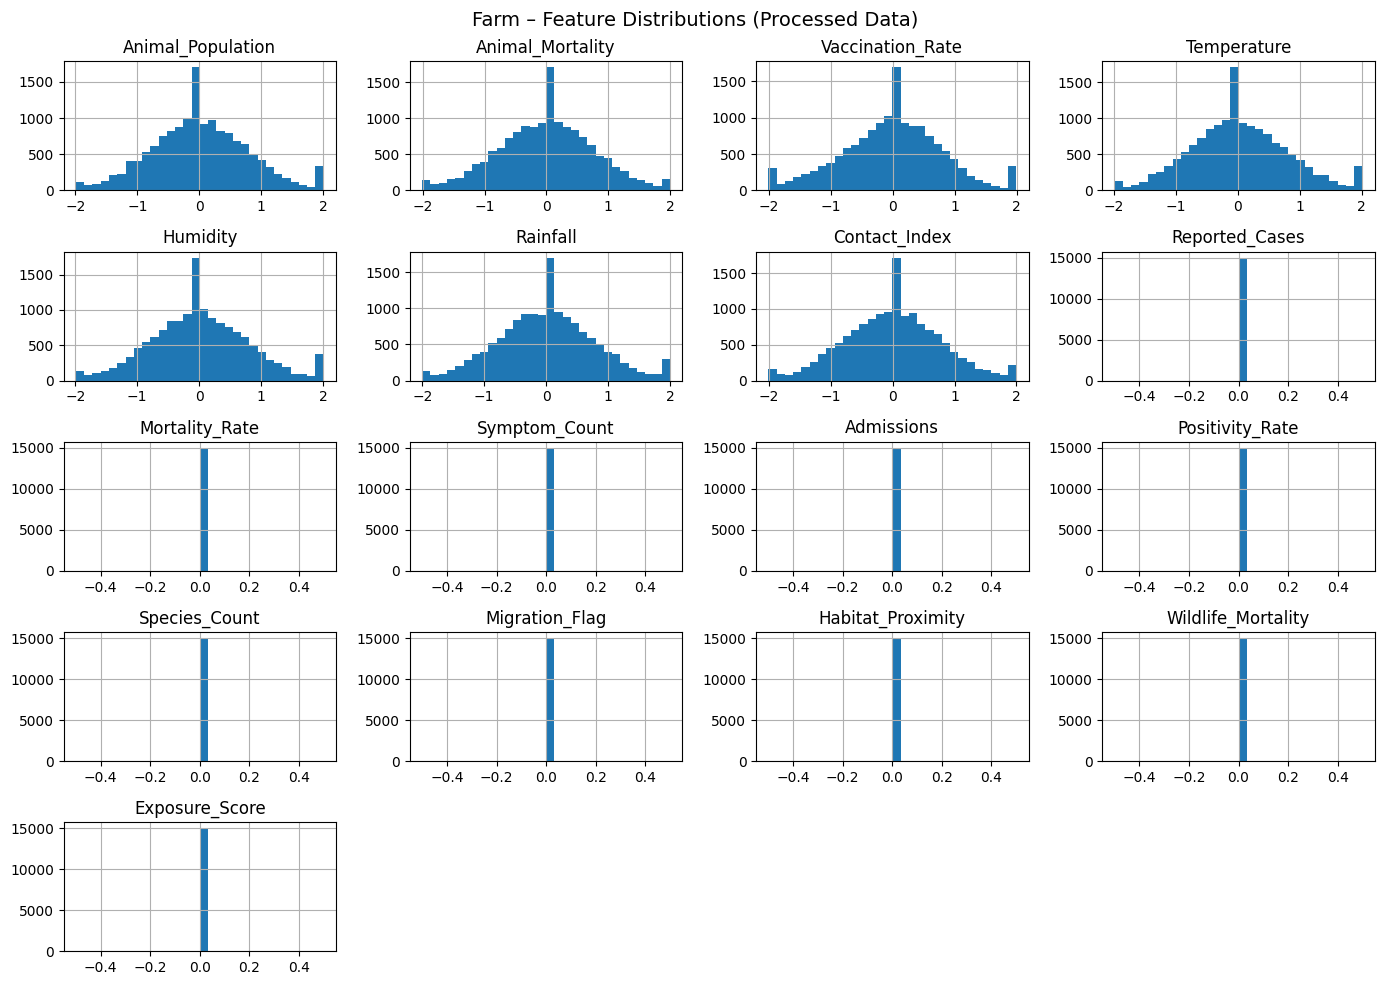

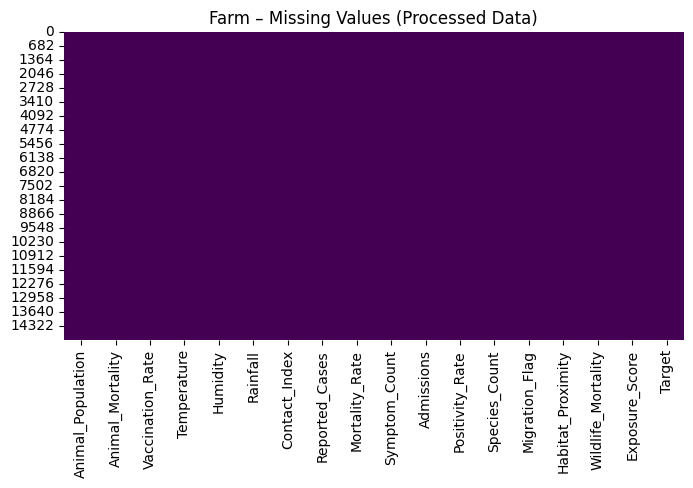

Missing values per column (Processed Data):
 Animal_Population     0
Animal_Mortality      0
Vaccination_Rate      0
Temperature           0
Humidity              0
Rainfall              0
Contact_Index         0
Reported_Cases        0
Mortality_Rate        0
Symptom_Count         0
Admissions            0
Positivity_Rate       0
Species_Count         0
Migration_Flag        0
Habitat_Proximity     0
Wildlife_Mortality    0
Exposure_Score        0
Target                0
dtype: int64


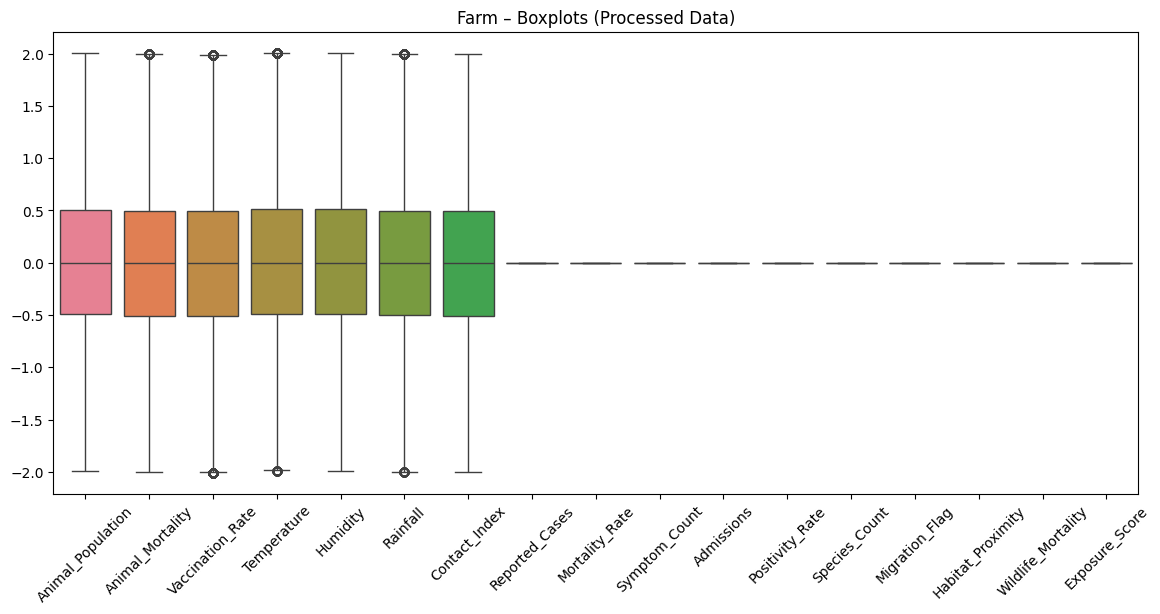


=== Hospital CLIENT DATA EXPLORATION ===

--- Before Preprocessing ---


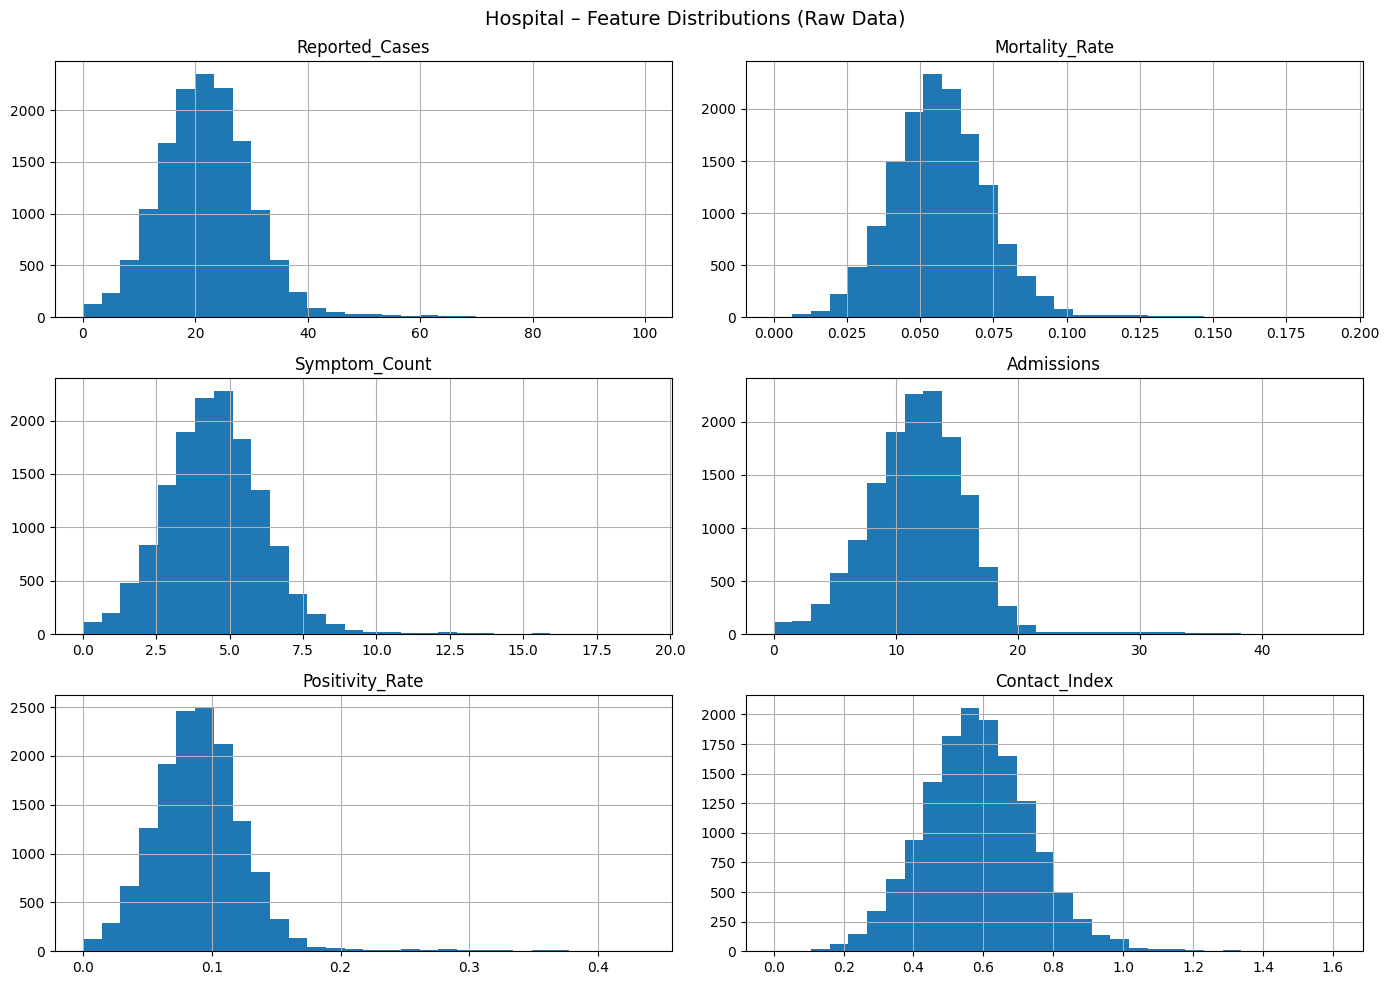

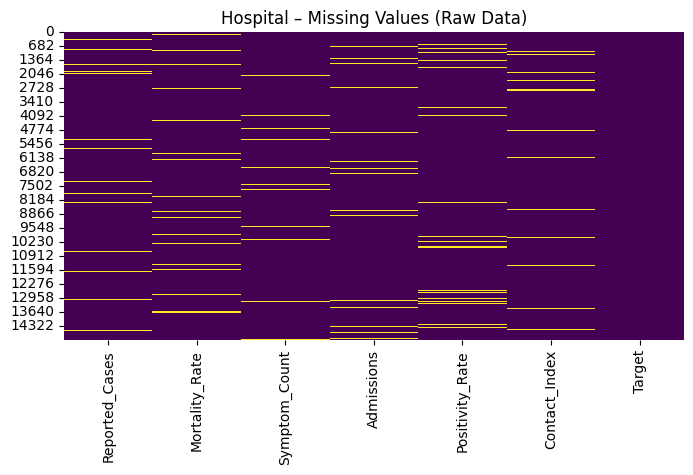

Missing values per column (Raw Data):
 Reported_Cases     750
Mortality_Rate     750
Symptom_Count      750
Admissions         750
Positivity_Rate    750
Contact_Index      750
Target               0
dtype: int64


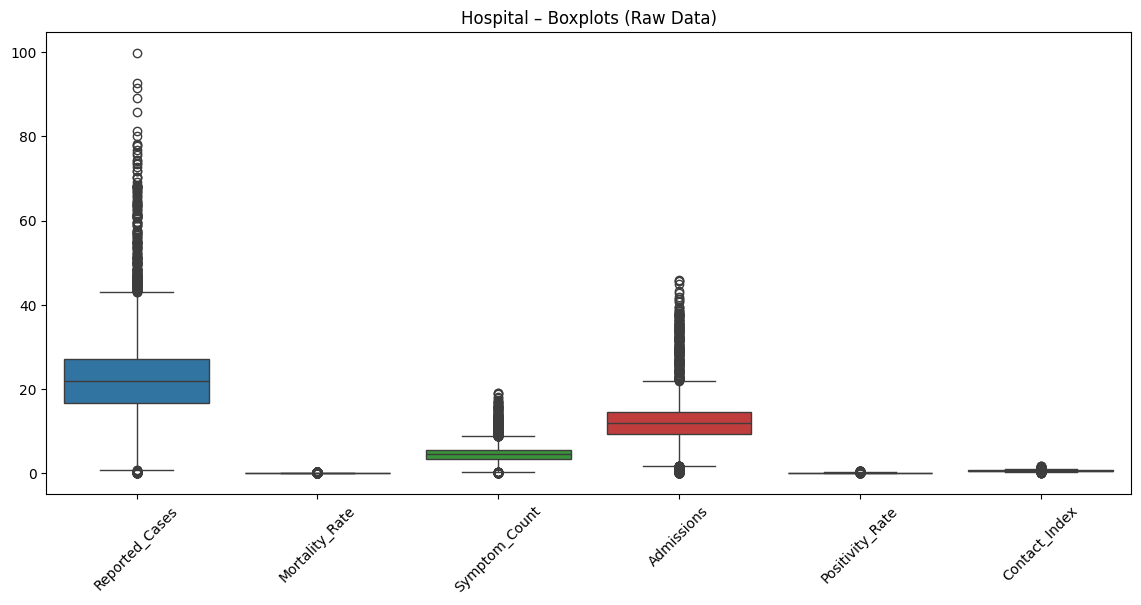


--- After Preprocessing ---


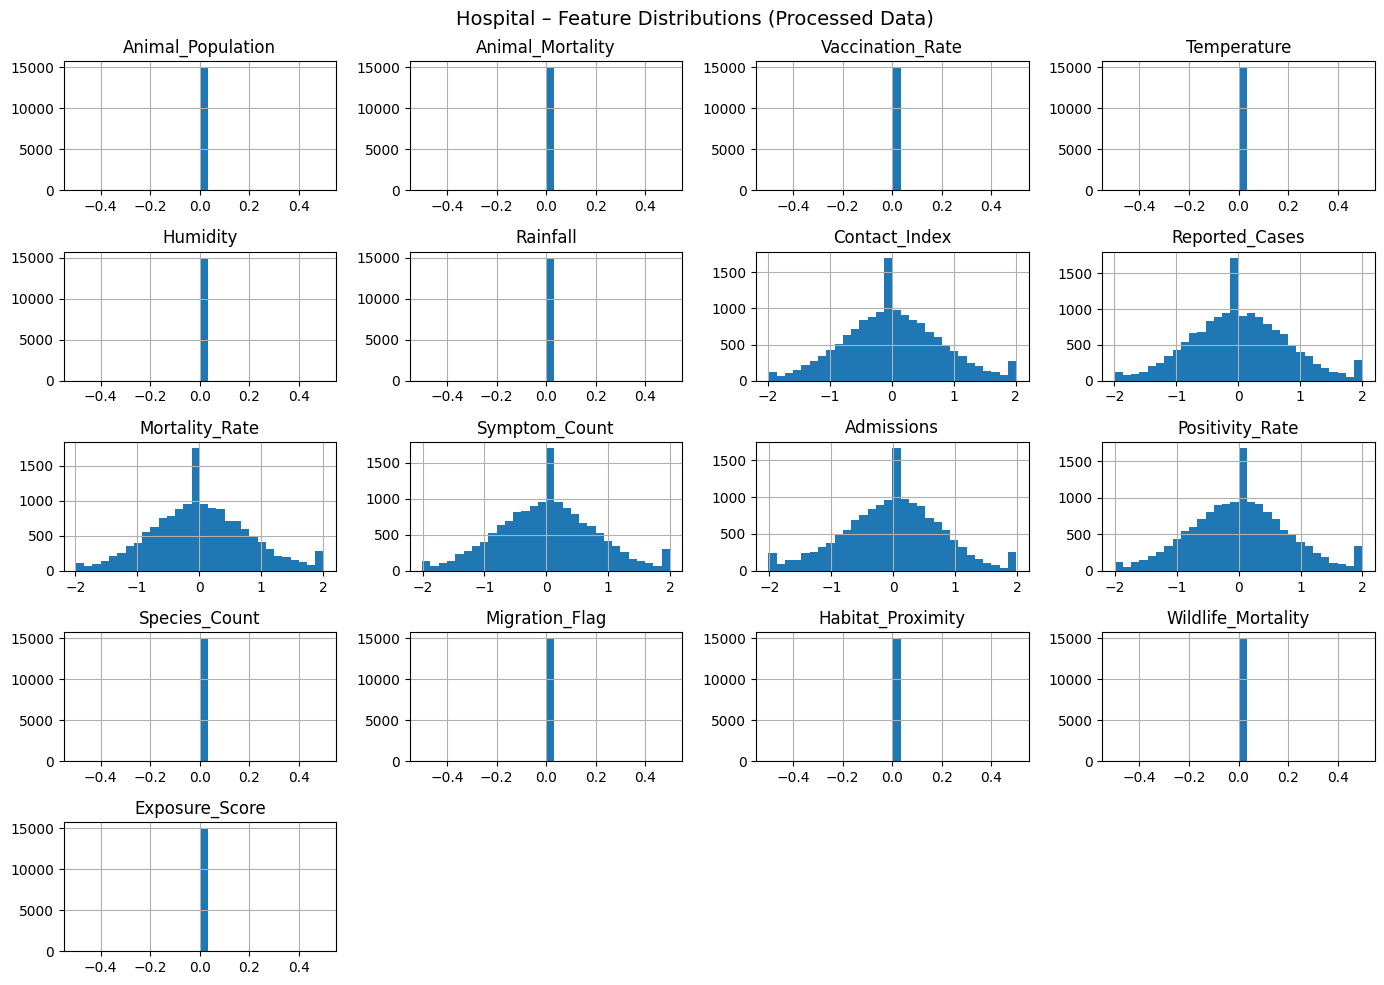

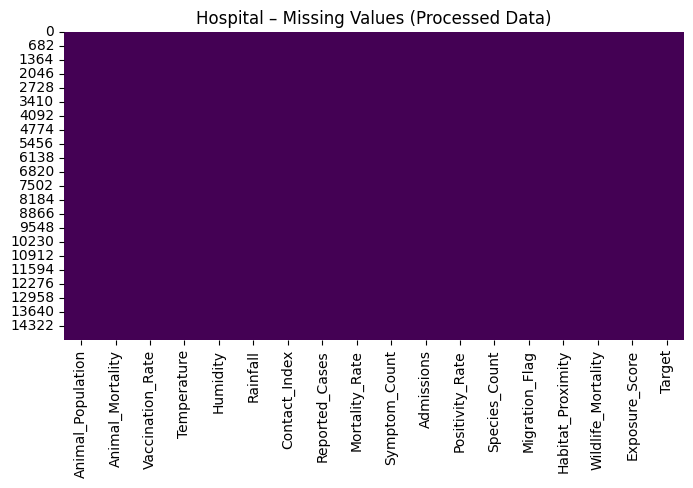

Missing values per column (Processed Data):
 Animal_Population     0
Animal_Mortality      0
Vaccination_Rate      0
Temperature           0
Humidity              0
Rainfall              0
Contact_Index         0
Reported_Cases        0
Mortality_Rate        0
Symptom_Count         0
Admissions            0
Positivity_Rate       0
Species_Count         0
Migration_Flag        0
Habitat_Proximity     0
Wildlife_Mortality    0
Exposure_Score        0
Target                0
dtype: int64


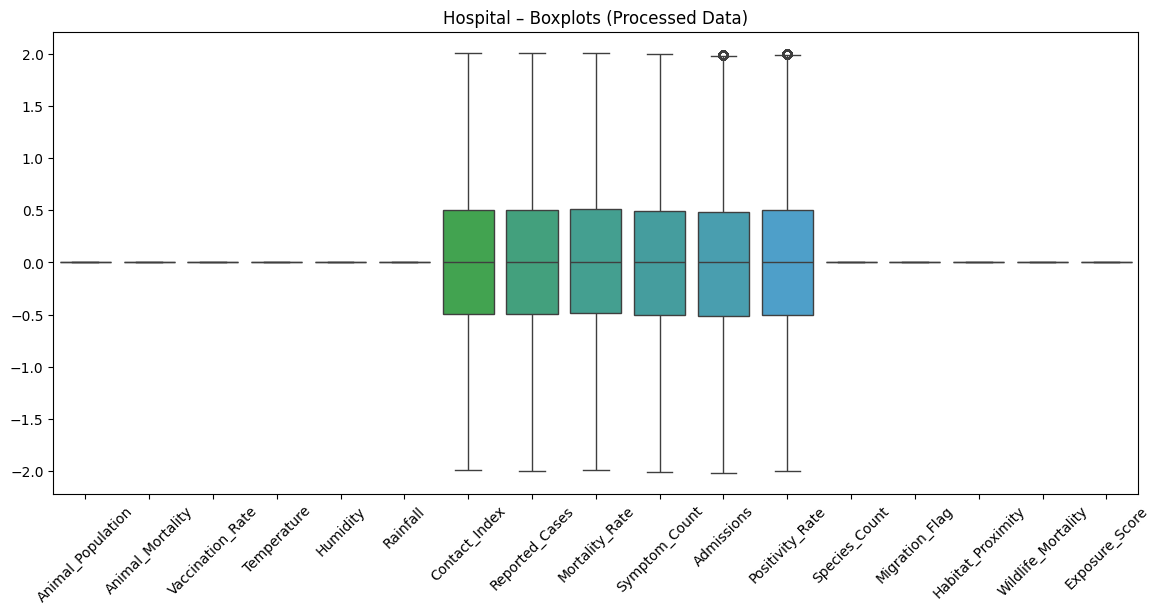


=== Wildlife CLIENT DATA EXPLORATION ===

--- Before Preprocessing ---


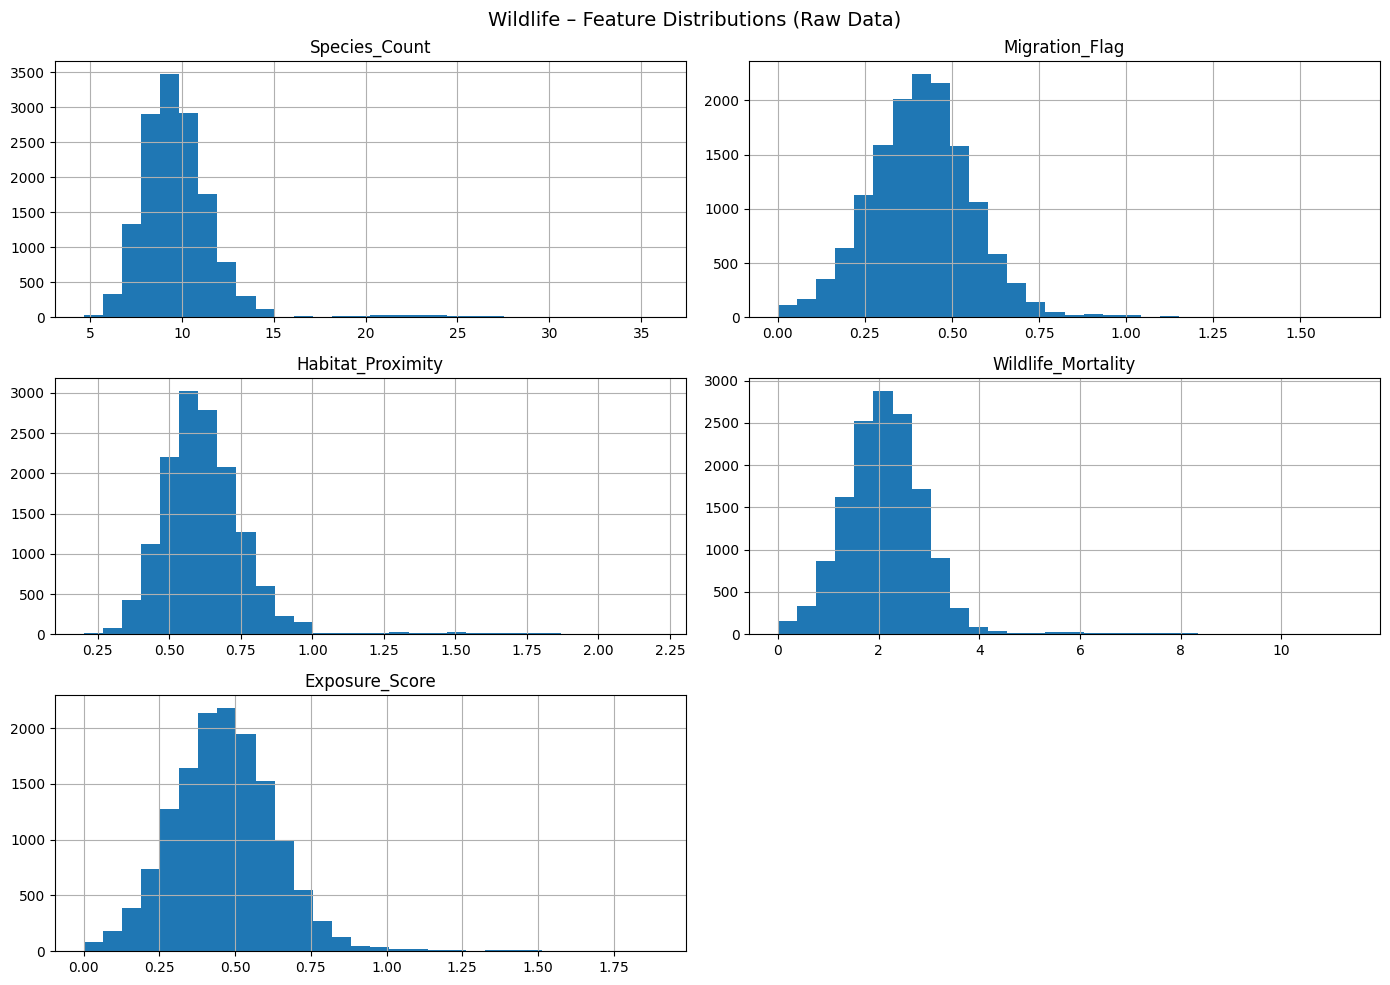

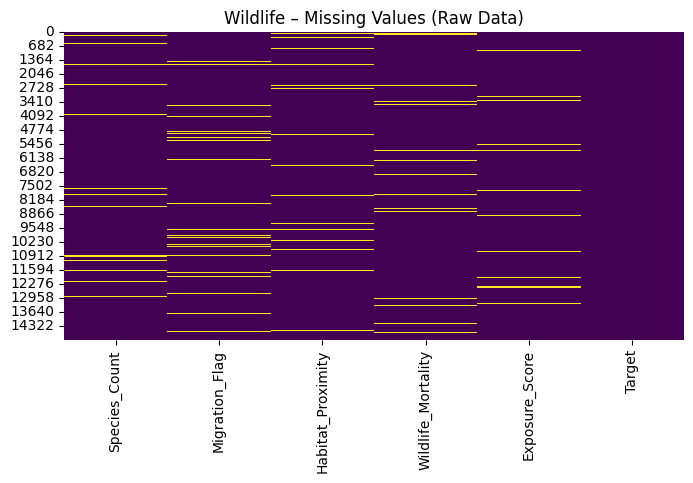

Missing values per column (Raw Data):
 Species_Count         750
Migration_Flag        750
Habitat_Proximity     750
Wildlife_Mortality    750
Exposure_Score        750
Target                  0
dtype: int64


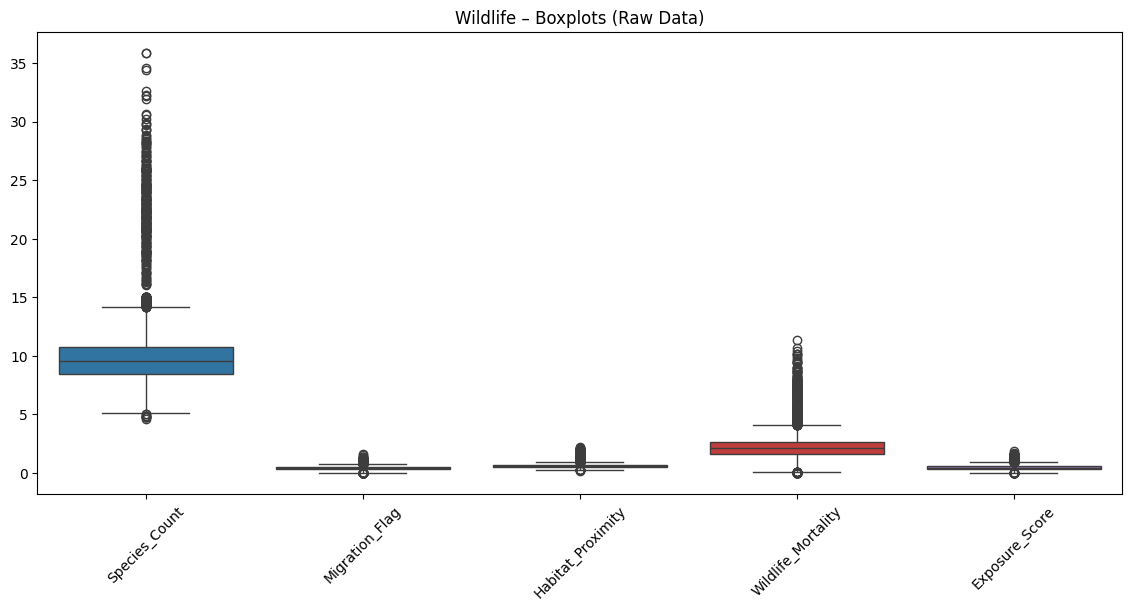


--- After Preprocessing ---


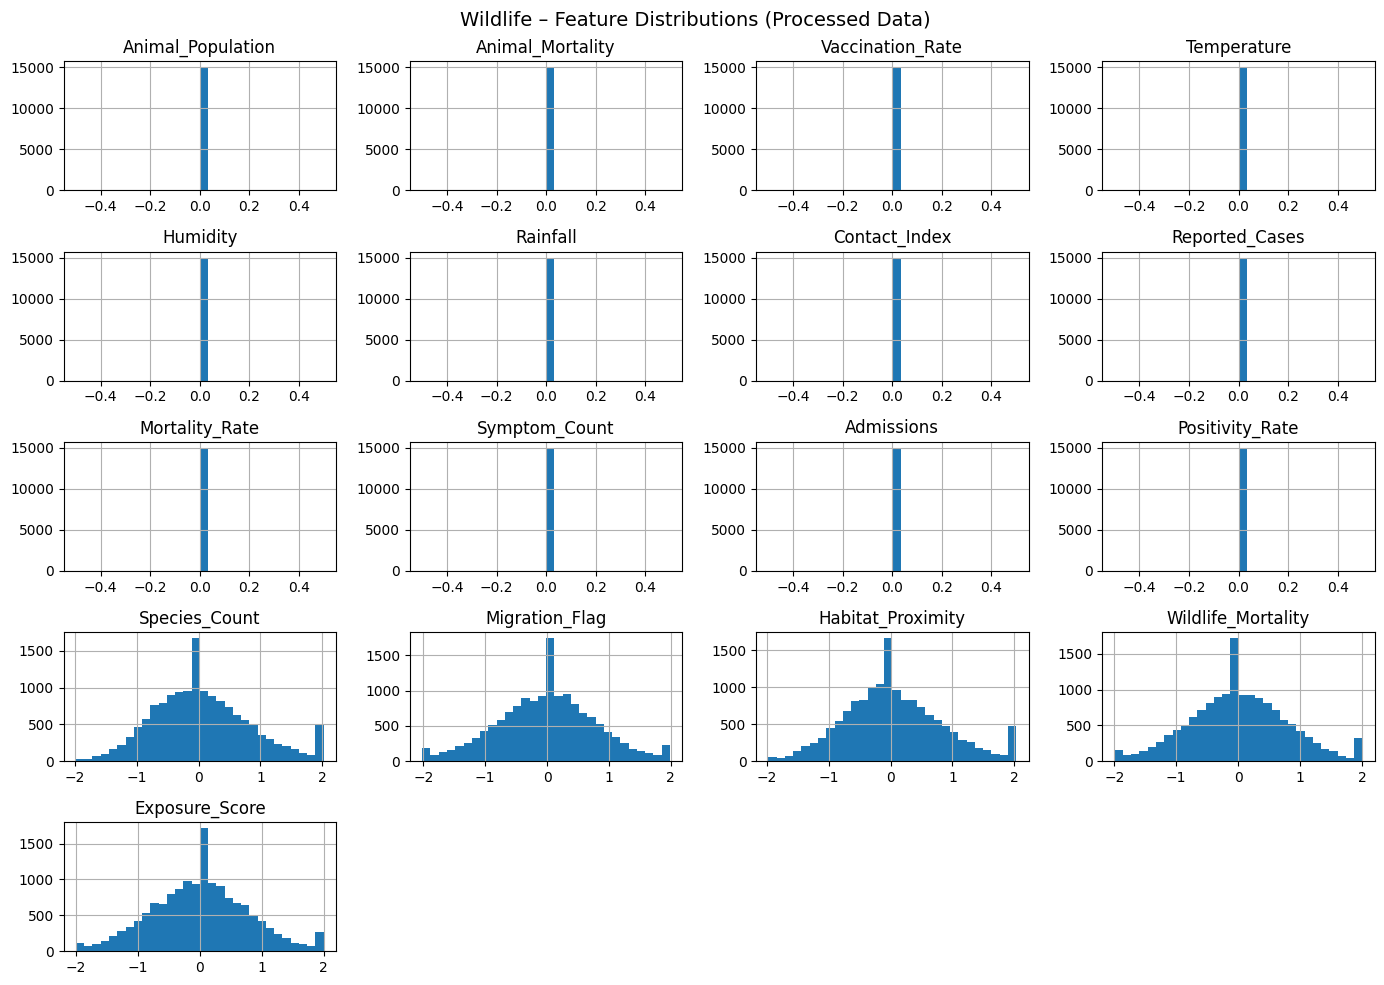

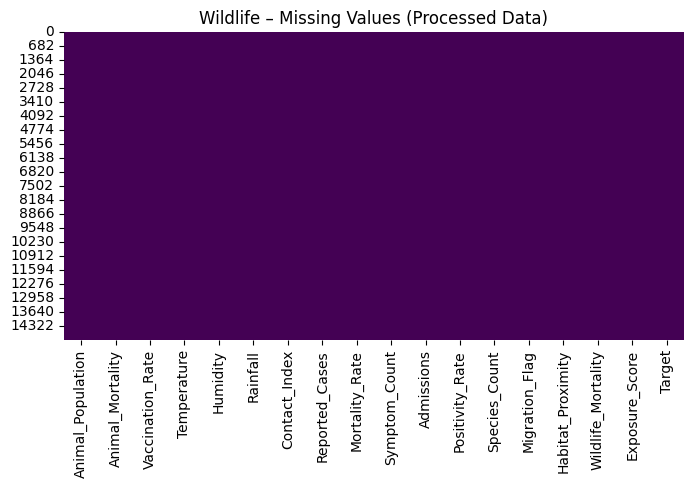

Missing values per column (Processed Data):
 Animal_Population     0
Animal_Mortality      0
Vaccination_Rate      0
Temperature           0
Humidity              0
Rainfall              0
Contact_Index         0
Reported_Cases        0
Mortality_Rate        0
Symptom_Count         0
Admissions            0
Positivity_Rate       0
Species_Count         0
Migration_Flag        0
Habitat_Proximity     0
Wildlife_Mortality    0
Exposure_Score        0
Target                0
dtype: int64


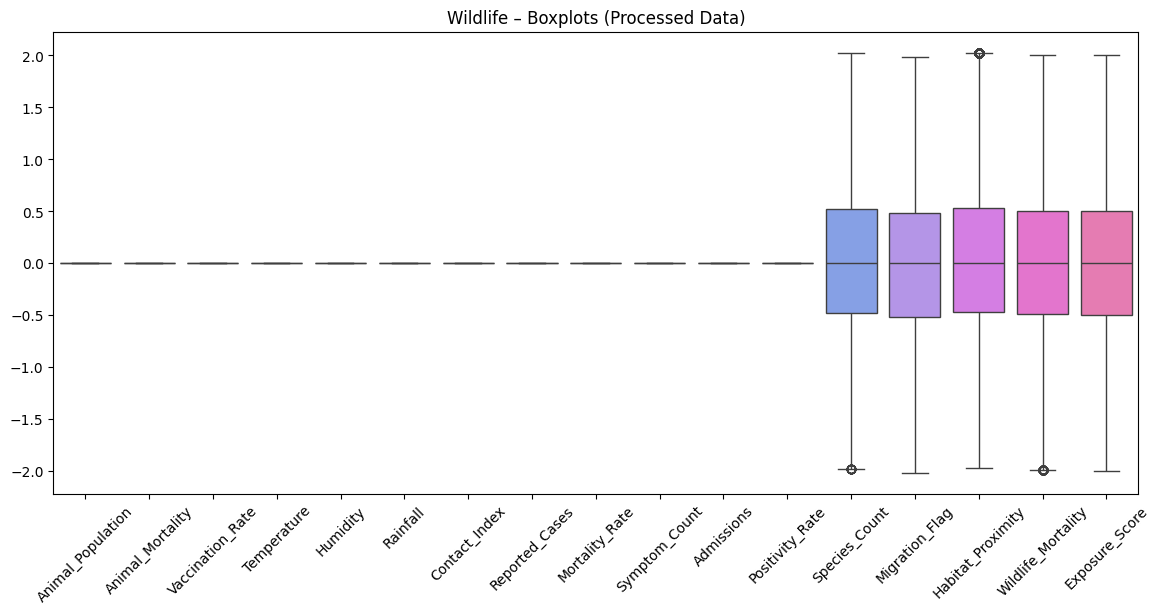

In [57]:
# ===============================
# 4. DATA EXPLORATION & PLOTS
# ===============================
def plot_distributions(df, client, title_suffix=""):
    """Plot histograms for all features."""
    features = df.drop(columns=["Target"])
    features.hist(figsize=(14, 10), bins=30)
    plt.suptitle(f"{client} – Feature Distributions {title_suffix}", fontsize=14)
    plt.tight_layout()
    plt.show()

def plot_missing_values(df, client, title_suffix=""):
    """Visualize missing values as a heatmap."""
    plt.figure(figsize=(8, 4))
    sns.heatmap(df.isna(), cbar=False, cmap="viridis")
    plt.title(f"{client} – Missing Values {title_suffix}")
    plt.show()
    print(f"Missing values per column {title_suffix}:\n", df.isna().sum())

def plot_boxplots(df, client, title_suffix=""):
    """Boxplots for detecting outliers."""
    features = df.drop(columns=["Target"])
    plt.figure(figsize=(14, 6))
    sns.boxplot(data=features)
    plt.xticks(rotation=45)
    plt.title(f"{client} – Boxplots {title_suffix}")
    plt.show()


# ===============================
# 5. DISPLAY BEFORE & AFTER PREPROCESSING
# ===============================
for client in CLIENTS:
    print(f"\n=== {client} CLIENT DATA EXPLORATION ===")
    df_raw = pd.read_csv(f"{DATA_DIR}/{client}_data.csv")

    # ----- Before preprocessing -----
    print("\n--- Before Preprocessing ---")
    plot_distributions(df_raw, client, "(Raw Data)")
    plot_missing_values(df_raw, client, "(Raw Data)")
    plot_boxplots(df_raw, client, "(Raw Data)")

    # ----- After preprocessing -----
    X_processed, y_processed, _, _ = preprocess_client_data(df_raw, client)
    df_processed = X_processed.copy()
    df_processed["Target"] = y_processed.values

    print("\n--- After Preprocessing ---")
    plot_distributions(df_processed, client, "(Processed Data)")
    plot_missing_values(df_processed, client, "(Processed Data)")
    plot_boxplots(df_processed, client, "(Processed Data)")


In [58]:
# ===============================
# 4. BUILD FDNN
# ===============================
def build_fdnn(input_dim):
    inputs = Input(shape=(input_dim,))
    x = Dense(64, activation="relu")(inputs)
    x = Dense(32, activation="relu")(x)
    outputs = Dense(3, activation="softmax")(x)
    model = Model(inputs, outputs)
    model.compile(optimizer=Adam(0.001),
                  loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
    return model


In [59]:
# ===============================
# 5. TRAIN LOCAL MODELS
# ===============================
local_models = {}
preprocessors = {}

for client in CLIENTS:
    print(f"\n=== TRAINING LOCAL MODEL: {client} ===")
    df = pd.read_csv(f"{DATA_DIR}/{client}_data.csv")
    X, y, imputer, scaler = preprocess_client_data(df, client)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    model = build_fdnn(GLOBAL_DIM)
    model.fit(X_train, y_train, epochs=15, batch_size=256, verbose=0)

    # Evaluation
    y_pred = np.argmax(model.predict(X_test), axis=1)
    acc = accuracy_score(y_test, y_pred)
    print(f"{client} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))

    # Save model & preprocessors
    client_dir = f"{BASE_DIR}/{client}"
    os.makedirs(client_dir, exist_ok=True)
    joblib.dump(imputer, f"{client_dir}/imputer.pkl")
    joblib.dump(scaler, f"{client_dir}/scaler.pkl")
    joblib.dump(CLIENT_FEATURES[client], f"{client_dir}/features.pkl")
    model.save(f"{client_dir}/fdnn_model.h5")

    local_models[client] = model
    preprocessors[client] = (imputer, scaler)


=== TRAINING LOCAL MODEL: Farm ===
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


Farm Accuracy: 0.9697
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       990
           1       0.96      0.95      0.96       990
           2       0.98      0.97      0.97      1020

    accuracy                           0.97      3000
   macro avg       0.97      0.97      0.97      3000
weighted avg       0.97      0.97      0.97      3000


=== TRAINING LOCAL MODEL: Hospital ===
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


Hospital Accuracy: 0.9810
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       990
           1       0.98      0.97      0.97       990
           2       0.98      0.98      0.98      1020

    accuracy                           0.98      3000
   macro avg       0.98      0.98      0.98      3000
weighted avg       0.98      0.98      0.98      3000


=== TRAINING LOCAL MODEL: Wildlife ===
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


Wildlife Accuracy: 0.9640
              precision    recall  f1-score   support

           0       0.98      0.97      0.98       990
           1       0.94      0.96      0.95       990
           2       0.98      0.97      0.97      1020

    accuracy                           0.96      3000
   macro avg       0.96      0.96      0.96      3000
weighted avg       0.96      0.96      0.96      3000



## Confuion matrix for each local clients

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


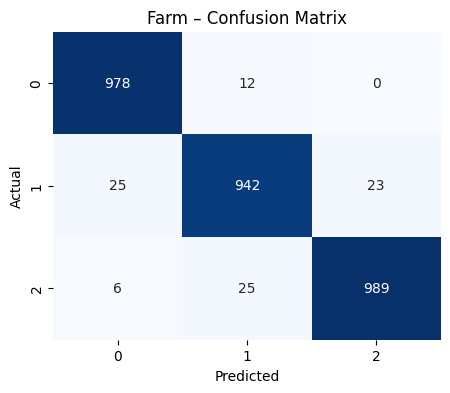

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


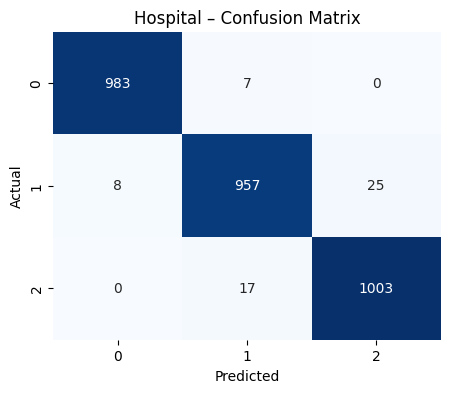

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


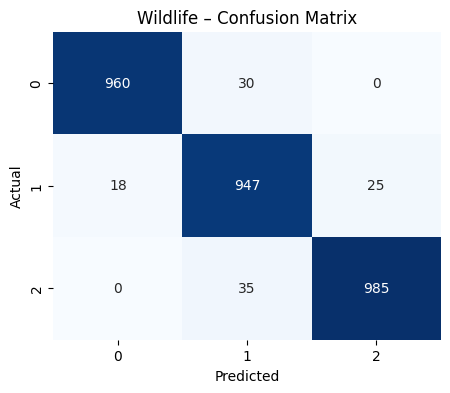

In [60]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ===============================
# 6. CONFUSION MATRIX PLOT
# ===============================
def plot_confusion(y_true, y_pred, client):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{client} – Confusion Matrix")
    plt.show()


# ===============================
# DISPLAY CONFUSION MATRIX FOR LOCAL MODELS
# ===============================
for client in CLIENTS:
    df = pd.read_csv(f"{DATA_DIR}/{client}_data.csv")
    X, y, _, _ = preprocess_client_data(df, client)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    model = local_models[client]
    y_pred = np.argmax(model.predict(X_test), axis=1)

    plot_confusion(y_test, y_pred, client)


In [61]:
# ===============================
# 6. FEDAVG
# ===============================
def fed_avg(models):
    weights = [model.get_weights() for model in models]
    avg_weights = []
    for layer_weights in zip(*weights):
        avg_weights.append(np.mean(layer_weights, axis=0))
    return avg_weights

global_model = build_fdnn(GLOBAL_DIM)
global_model(np.zeros((1, GLOBAL_DIM)))  # initialize weights
global_model.set_weights(fed_avg(list(local_models.values())))


In [ ]:
# Save global model
os.makedirs("saved_global_model", exist_ok=True)
global_model.save("saved_global_model/global_fdnn_model.h5")
print("\n✅ Global federated model saved successfully")


✅ Global federated model saved successfully


In [63]:
# ===============================
# 7. FEATURE EXTRACTION + XGBOOST
# ===============================
from tensorflow.keras.models import Model
import xgboost as xgb

# Feature extractor: output of second-last Dense layer
feature_extractor = Model(
    inputs=global_model.input,
    outputs=global_model.layers[-2].output
)

# Prepare feature matrix for all clients
X_all, y_all = [], []

for client in CLIENTS:
    df = pd.read_csv(f"{DATA_DIR}/{client}_data.csv")
    X, y, imputer, scaler = preprocess_client_data(df, client)

    # Extract features from global model
    features_nn = feature_extractor.predict(X, batch_size=512, verbose=0)
    X_all.append(features_nn)
    y_all.append(y.values)

# Combine all client data
X_all = np.vstack(X_all)
y_all = np.concatenate(y_all)
print("Final feature matrix shape:", X_all.shape)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

# XGBoost classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)


Final feature matrix shape: (45000, 32)


,objective,'multi:softmax'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [64]:
# ===============================
# 8. FINAL EVALUATION
# ===============================
y_pred = xgb_model.predict(X_test)

print("\n🎯 FINAL RESULTS — Federated FDNN + XGBoost")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


🎯 FINAL RESULTS — Federated FDNN + XGBoost
Accuracy: 0.9612222222222222
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      2970
           1       0.93      0.95      0.94      2970
           2       0.98      0.96      0.97      3060

    accuracy                           0.96      9000
   macro avg       0.96      0.96      0.96      9000
weighted avg       0.96      0.96      0.96      9000



In [ ]:
# 2️⃣ Save feature matrix and labels as CSV
Xy_df = pd.DataFrame(X_all)
Xy_df["Target"] = y_all
Xy_df.to_csv(f"XGBoost_input_features.csv", index=False)
print("✅ XGBoost input features saved as CSV")

✅ XGBoost input features saved as CSV


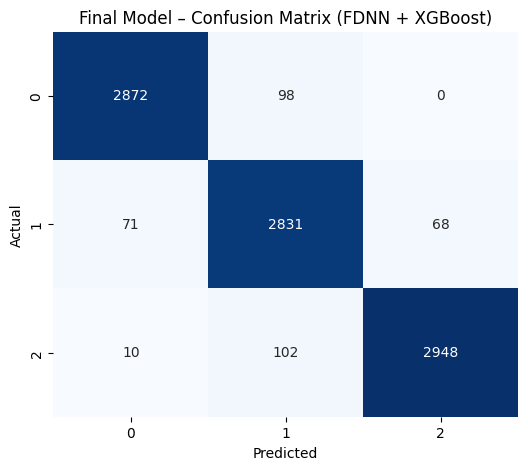

In [65]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ===============================
# CONFUSION MATRIX — FEDERATED + XGBOOST
# ===============================
def plot_final_confusion(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Final Model – Confusion Matrix (FDNN + XGBoost)")
    plt.show()

# Plot it
plot_final_confusion(y_test, y_pred)


In [66]:
# ===============================
# 1. SAVE XGBOOST MODEL
# ===============================
os.makedirs("saved_global_model", exist_ok=True)
xgb_model_path = "saved_global_model/xgb_model.pkl"
joblib.dump(xgb_model, xgb_model_path)
print(f"✅ XGBoost model saved at {xgb_model_path}")



✅ XGBoost model saved at saved_global_model/xgb_model.pkl


In [68]:
# ===============================
# 2. SAMPLE PREDICTION — LOCAL MODEL
# ===============================
def predict_local(client, sample_df):
    client_dir = f"{BASE_DIR}/{client}"
    
    # Load preprocessing objects
    imputer = joblib.load(f"{client_dir}/imputer.pkl")
    scaler = joblib.load(f"{client_dir}/scaler.pkl")
    features = joblib.load(f"{client_dir}/features.pkl")
    model = load_model(f"{client_dir}/fdnn_model.h5")
    
    # Create global-aligned input
    X_global = pd.DataFrame(0, index=sample_df.index, columns=GLOBAL_FEATURES)
    
    # Only use client features
    X = sample_df[features]
    X_imputed = imputer.transform(X)
    X_capped = cap_outliers_iqr(pd.DataFrame(X_imputed, columns=features))
    X_scaled = scaler.transform(X_capped)
    
    # Place scaled features in global-aligned DataFrame
    X_global[features] = X_scaled
    
    # Predict
    preds = model.predict(X_global)
    return np.argmax(preds, axis=1)


# Example local prediction
sample_local = pd.read_csv(f"{DATA_DIR}/Farm_data.csv").head(5)
local_preds = predict_local("Farm", sample_local.drop(columns=["Target"]))
print("Local FDNN predictions:", local_preds)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
Local FDNN predictions: [0 2 1 1 2]


In [116]:
# ===============================
# GLOBAL PREDICTION FUNCTION
# ===============================
def predict_global_only(sample_df):
    X_global = pd.DataFrame(0, index=sample_df.index, columns=GLOBAL_FEATURES)

    for client in CLIENTS:
        features = CLIENT_FEATURES[client]
        client_dir = f"{BASE_DIR}/{client}"

        # Load preprocessors
        imputer = joblib.load(f"{client_dir}/imputer.pkl")
        scaler = joblib.load(f"{client_dir}/scaler.pkl")
        median_vals = joblib.load(f"{client_dir}/median_vals.pkl")  # saved during training

        # Prepare client features
        X_client = pd.DataFrame(0, index=sample_df.index, columns=features)
        for f in features:
            if f in sample_df.columns:
                X_client[f] = sample_df[f]
            else:
                X_client[f] = median_vals[f]  # fill missing features

        # Preprocessing
        X_imputed = imputer.transform(X_client)
        X_capped = cap_outliers_iqr(pd.DataFrame(X_imputed, columns=features))
        X_scaled = scaler.transform(X_capped)

        # Place in global dataframe
        X_global[features] = X_scaled

    # Extract features from global FDNN
    feature_extractor = Model(
        inputs=global_model.input,
        outputs=global_model.layers[-2].output
    )
    features_nn = feature_extractor.predict(X_global, batch_size=512, verbose=0)

    # Predict with XGBoost
    preds = xgb_model.predict(features_nn)
    return preds


# ===============================
# SAMPLE GLOBAL PREDICTION
# ===============================
sample_global = pd.read_csv(f"{DATA_DIR}/Farm_data.csv").head(10)
global_preds = predict_global_only(sample_global.drop(columns=["Target"]))
print("Global FDNN + XGBoost predictions:", global_preds)


Global FDNN + XGBoost predictions: [0 2 2 1 2 2 2 0 0 1]


## Catboost 

0:	learn: 1.0460911	total: 252ms	remaining: 1m 15s
50:	learn: 0.3243181	total: 2.68s	remaining: 13.1s
100:	learn: 0.2155398	total: 4.92s	remaining: 9.69s
150:	learn: 0.1767289	total: 7.12s	remaining: 7.03s
200:	learn: 0.1545706	total: 9.29s	remaining: 4.58s
250:	learn: 0.1392725	total: 11.4s	remaining: 2.23s
299:	learn: 0.1274876	total: 13.5s	remaining: 0us
Accuracy: 0.9486666666666667
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      2970
           1       0.91      0.94      0.92      2970
           2       0.97      0.95      0.96      3060

    accuracy                           0.95      9000
   macro avg       0.95      0.95      0.95      9000
weighted avg       0.95      0.95      0.95      9000



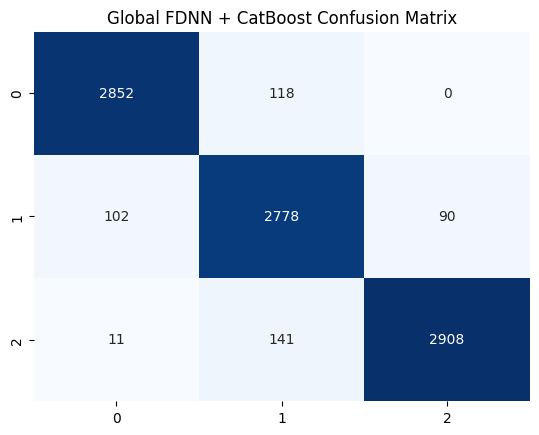

In [120]:
# X_all should be the preprocessed global features, not the NN outputs
# Make sure X_all has shape (num_samples, GLOBAL_DIM)

# Example: recreate X_all from local preprocessors
X_all_global = []
y_all_global = []

for client in CLIENTS:
    df = pd.read_csv(f"{DATA_DIR}/{client}_data.csv")
    X, y, imputer, scaler = preprocess_client_data(df, client)
    X_all_global.append(X.values)
    y_all_global.append(y.values)

X_all_global = np.vstack(X_all_global)
y_all_global = np.concatenate(y_all_global)

# Extract features using the global FDNN
feature_extractor = Model(
    inputs=global_model.input,
    outputs=global_model.layers[-2].output
)

X_features = feature_extractor.predict(X_all_global, batch_size=512, verbose=0)

# Now train CatBoost
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_all_global, test_size=0.2, random_state=42, stratify=y_all_global
)

cat_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function='MultiClass',
    verbose=50,
    random_seed=42
)

cat_model.fit(X_train, y_train)

# Evaluate
y_pred = cat_model.predict(X_test).astype(int)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Global FDNN + CatBoost Confusion Matrix")
plt.show()


# Accuracy Comparison

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


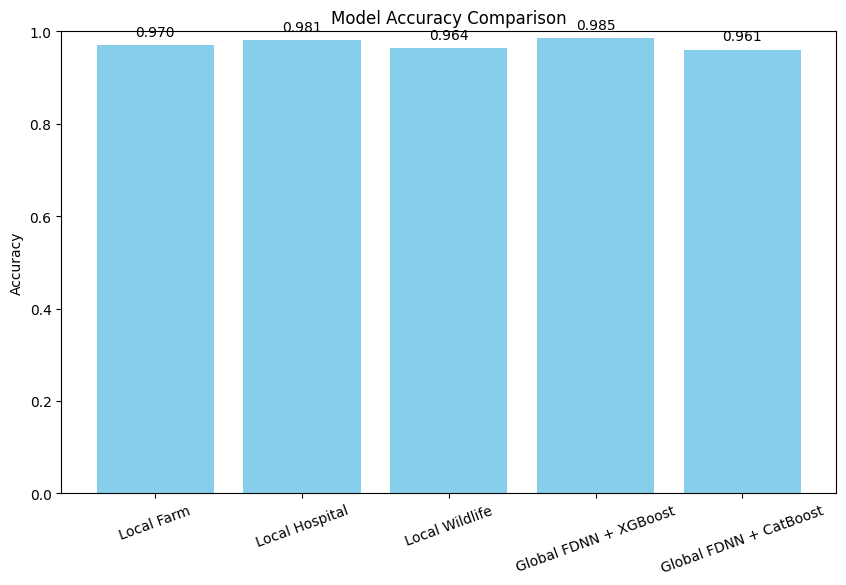

In [123]:
accuracies = {}

# ---- Local FDNNs ----
for client in CLIENTS:
    df = pd.read_csv(f"{DATA_DIR}/{client}_data.csv")
    X, y, _, _ = preprocess_client_data(df, client)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    model = local_models[client]
    y_pred = np.argmax(model.predict(X_test), axis=1)
    accuracies[f"Local {client}"] = accuracy_score(y_test, y_pred)

# ---- Global FDNN + XGBoost ----
# Convert raw X_test into FDNN embeddings
X_test_fdnn_features = feature_extractor.predict(X_test, batch_size=512, verbose=0)
y_pred_xgb = xgb_model.predict(X_test_fdnn_features)
accuracies["Global FDNN + XGBoost"] = accuracy_score(y_test, y_pred_xgb)

# ---- Global FDNN + CatBoost ----
y_pred_cat = cat_model.predict(X_test_fdnn_features).astype(int)
accuracies["Global FDNN + CatBoost"] = accuracy_score(y_test, y_pred_cat)

# ---- Plot ----
plt.figure(figsize=(10, 6))
plt.bar(accuracies.keys(), accuracies.values(), color='skyblue')
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20)
for i, acc in enumerate(accuracies.values()):
    plt.text(i, acc + 0.02, f"{acc:.3f}", ha='center')
plt.show()


c:\Users\dayav\anaconda3\envs\aienv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\dayav\AppData\Local\Temp\ipykernel_26080\2641880266.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_fdnn_features, plot_type="bar", feature_names=[f"FDNN_feat_{i}" for i in range(X_test_fdnn_features.shape[1])])


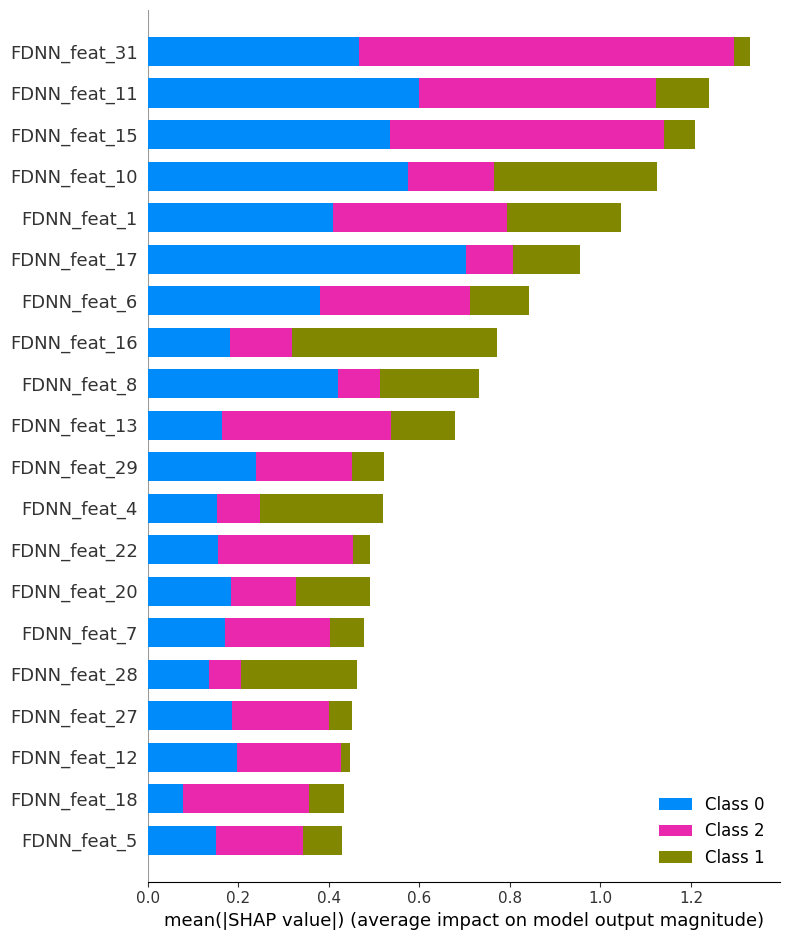

C:\Users\dayav\AppData\Local\Temp\ipykernel_26080\2641880266.py:14: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_fdnn_features, feature_names=[f"FDNN_feat_{i}" for i in range(X_test_fdnn_features.shape[1])])
c:\Users\dayav\anaconda3\envs\aienv\lib\site-packages\shap\plots\_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
c:\Users\dayav\anaconda3\envs\aienv\lib\site-packages\shap\plots\_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitl

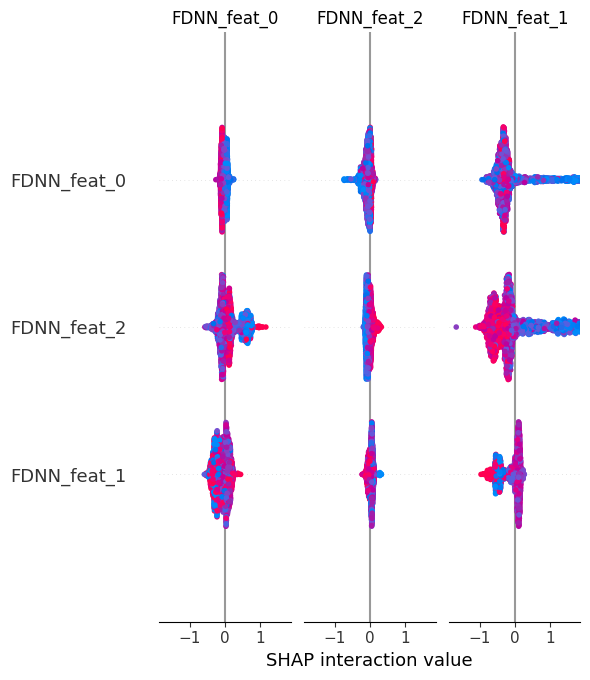

In [124]:
import shap

# Use the FDNN features (from last hidden layer) for XGBoost
X_test_fdnn_features = feature_extractor.predict(X_test, batch_size=512, verbose=0)

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_fdnn_features)

# Plot summary (bar plot)
shap.summary_plot(shap_values, X_test_fdnn_features, plot_type="bar", feature_names=[f"FDNN_feat_{i}" for i in range(X_test_fdnn_features.shape[1])])

# Optional: summary plot with beeswarm
shap.summary_plot(shap_values, X_test_fdnn_features, feature_names=[f"FDNN_feat_{i}" for i in range(X_test_fdnn_features.shape[1])])


C:\Users\dayav\AppData\Local\Temp\ipykernel_26080\1857578953.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=importance_df, palette="viridis")


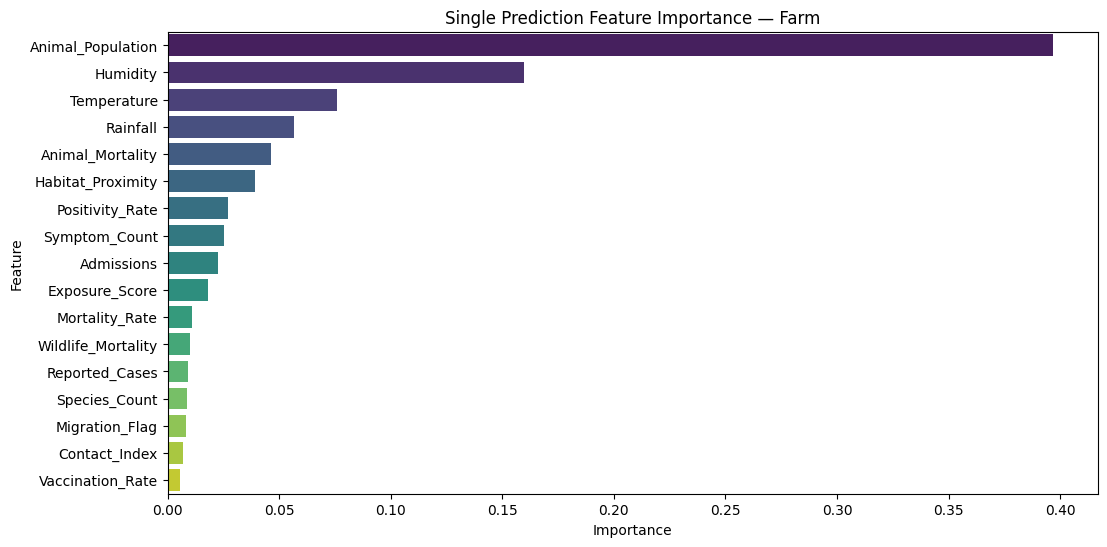

Predicted class: 0
               Feature  Importance
0    Animal_Population    0.396882
4             Humidity    0.159802
3          Temperature    0.075755
5             Rainfall    0.056509
1     Animal_Mortality    0.046204
14   Habitat_Proximity    0.039160
11     Positivity_Rate    0.026963
9        Symptom_Count    0.025403
10          Admissions    0.022583
16      Exposure_Score    0.018305
8       Mortality_Rate    0.010990
15  Wildlife_Mortality    0.010018
7       Reported_Cases    0.009285
12       Species_Count    0.008911
13      Migration_Flag    0.008106
6        Contact_Index    0.006874
2     Vaccination_Rate    0.005687


In [142]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import load_model
import joblib

def fdnn_local_single_prediction_importance(client, sample_df):
    client_dir = f"{BASE_DIR}/{client}"
    
    # Load model and preprocessors
    model = load_model(f"{client_dir}/fdnn_model.h5")
    imputer = joblib.load(f"{client_dir}/imputer.pkl")
    scaler = joblib.load(f"{client_dir}/scaler.pkl")
    features = joblib.load(f"{client_dir}/features.pkl")
    
    # Preprocess single sample
    X_global = pd.DataFrame(0, index=sample_df.index, columns=GLOBAL_FEATURES)
    X = sample_df[features]
    X_imputed = imputer.transform(X)
    X_capped = cap_outliers_iqr(pd.DataFrame(X_imputed, columns=features))
    X_scaled = scaler.transform(X_capped)
    X_global[features] = X_scaled
    
    # Convert to tf.Variable for gradient computation
    X_tensor = tf.convert_to_tensor(X_global.values, dtype=tf.float32)
    
    with tf.GradientTape() as tape:
        tape.watch(X_tensor)
        preds = model(X_tensor)
        class_idx = tf.argmax(preds[0])  # predicted class for first sample
        pred_score = preds[0, class_idx]
    
    grads = tape.gradient(pred_score, X_tensor).numpy()[0]  # gradients w.r.t features
    
    # Absolute gradients as feature importance
    importance = np.abs(grads)
    
    # Plot
    importance_df = pd.DataFrame({
        "Feature": GLOBAL_FEATURES,
        "Importance": importance
    }).sort_values(by="Importance", ascending=False)
    
    plt.figure(figsize=(12,6))
    sns.barplot(x="Importance", y="Feature", data=importance_df, palette="viridis")
    plt.title(f"Single Prediction Feature Importance — {client}")
    plt.show()
    
    # Return predicted class and importance values
    return int(class_idx.numpy()), importance_df

# -------------------------------
# Example usage (first row)
# -------------------------------
sample_local = pd.read_csv(f"{DATA_DIR}/Farm_data.csv").head(1)
pred_class, feature_imp = fdnn_local_single_prediction_importance("Farm", sample_local.drop(columns=["Target"]))
print("Predicted class:", pred_class)
print(feature_imp)
